In [1]:
import pandas as pd
# Load the cleaned data
df = pd.read_csv("../Data/lendingclub_full_encoded.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,addr_state,dti,...,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_major_purchase,purpose_medical,purpose_other,purpose_small_business,verification_status_Source Verified,verification_status_Verified
0,3600.0,3600.0,3600.0,36,13.99,123.03,10.0,55000.0,PA,5.91,...,False,False,True,False,False,False,False,False,False,False
1,24700.0,24700.0,24700.0,36,11.99,820.28,10.0,65000.0,SD,16.06,...,False,False,False,False,False,False,False,True,False,False
2,20000.0,20000.0,20000.0,60,10.78,432.66,10.0,63000.0,IL,10.78,...,False,False,False,True,False,False,False,False,False,False
3,10400.0,10400.0,10400.0,60,22.45,289.91,3.0,104433.0,PA,25.37,...,False,False,False,False,True,False,False,False,True,False
4,11950.0,11950.0,11950.0,36,13.44,405.18,4.0,34000.0,GA,10.20,...,True,False,True,False,False,False,False,False,True,False


In [2]:
# Check data state
print(df.shape)
print(df.columns)
print(df['loan_default'].value_counts(normalize=True))

(611780, 105)
Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'emp_length', 'annual_inc', 'addr_state', 'dti',
       ...
       'home_ownership_RENT', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_home_improvement',
       'purpose_major_purchase', 'purpose_medical', 'purpose_other',
       'purpose_small_business', 'verification_status_Source Verified',
       'verification_status_Verified'],
      dtype='str', length=105)
loan_default
0    0.788836
1    0.211164
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# STEP 1: Reload from main dataframe 
# Make a copy to avoid modifying original
df_model = df.copy()

# STEP 2: Define ALL columns that leak information
leakage_cols = [
    'loan_status', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'last_pymnt_d', 'last_pymnt_amnt', 'recoveries', 'collection_recovery_fee',
    'out_prncp', 'out_prncp_inv', 'next_pymnt_d'
]

# STEP 3: Drop leakage columns + target from features
X = df_model.drop(columns=[*leakage_cols, 'loan_default'], errors='ignore')
y = df_model['loan_default']

# STEP 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# STEP 5: Drop non-numeric cols (like strings accidentally left)
X_train = X_train.select_dtypes(include='number')
X_test = X_test[X_train.columns]  # align test columns

# STEP 6: Fill missing values with training medians
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# STEP 7: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 8: Fit logistic regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# STEP 9: Evaluate
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94     96519
           1       0.72      0.90      0.80     25837

    accuracy                           0.91    122356
   macro avg       0.85      0.91      0.87    122356
weighted avg       0.92      0.91      0.91    122356


Confusion Matrix:
 [[87619  8900]
 [ 2513 23324]]

ROC-AUC Score: 0.9572


In [4]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.7356433056923626


In [5]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

c:\Users\anhkh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:49:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_proba_xgb), 4))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94     96519
           1       0.71      0.92      0.80     25837

    accuracy                           0.90    122356
   macro avg       0.84      0.91      0.87    122356
weighted avg       0.92      0.90      0.91    122356


Confusion Matrix:
 [[87015  9504]
 [ 2191 23646]]

ROC-AUC Score: 0.9613


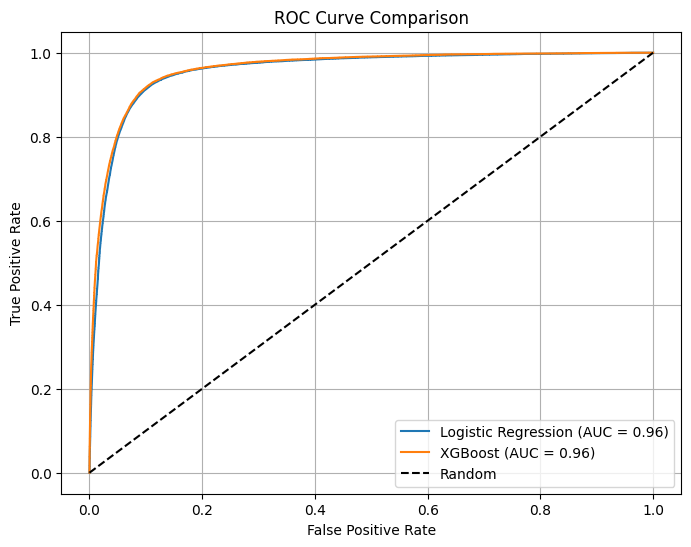

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba)
roc_auc_log = auc(fpr_log, tpr_log)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot both ROC Curves
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

# Baseline
plt.plot([0,1], [0,1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()

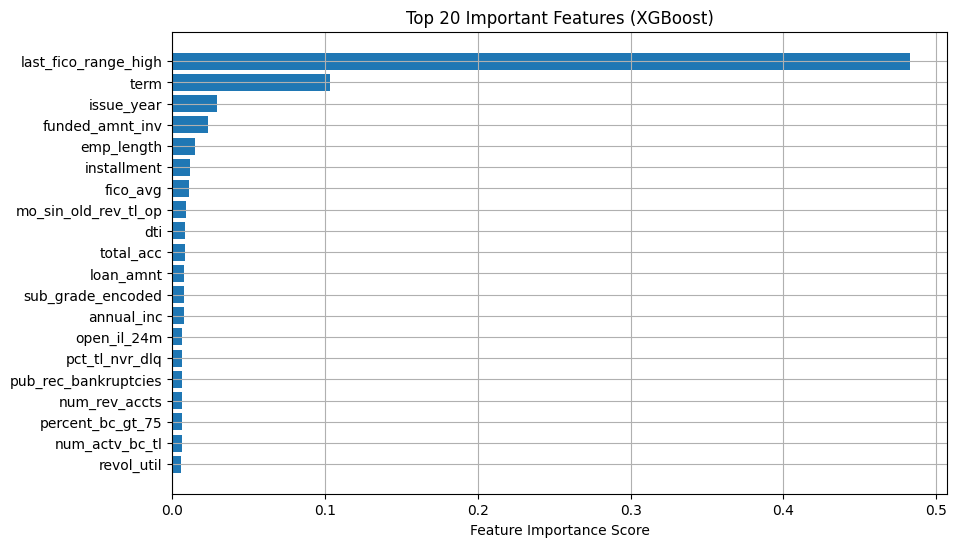


Top 10 Important Features:
                 Feature  Importance
17  last_fico_range_high    0.482998
3                   term    0.103471
74            issue_year    0.029176
2        funded_amnt_inv    0.023309
6             emp_length    0.014627
5            installment    0.011658
77              fico_avg    0.010934
45  mo_sin_old_rev_tl_op    0.008740
8                    dti    0.008260
16             total_acc    0.008190


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get feature importances from XGBoost model
feature_importances = xgb_model.feature_importances_

# Step 2: Map to column names
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Step 3: Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Step 4: Plot Top 20 Features
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Important Features (XGBoost)')
plt.grid()
plt.show()

# Step 5: (Optional) Show Top 10 Features Textually
print("\nTop 10 Important Features:")
print(importance_df.head(10))

c:\Users\anhkh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


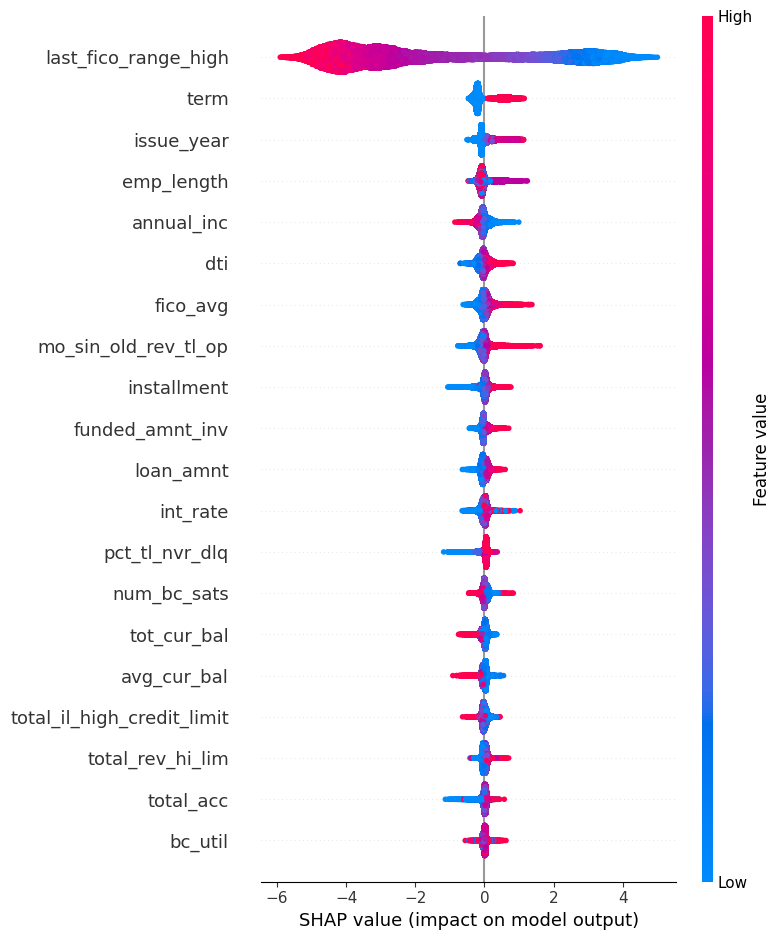

In [9]:
import shap

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Get SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Big summary plot
shap.summary_plot(shap_values, X_test)

In [10]:
y_pred_train = xgb_model.predict(X_train)
y_proba_train = xgb_model.predict_proba(X_train)[:,1]

from sklearn.metrics import roc_auc_score

print("Train AUC:", roc_auc_score(y_train, y_proba_train))
print("Test AUC:", roc_auc_score(y_test, y_proba_xgb))


Train AUC: 0.972435737060301
Test AUC: 0.9613255101775269
